
# Nevergrad first call
Quick notebook to exercise the optimization step (Nevergrad) with the cached pipeline. Adjust overrides to control runtime and target.


In [1]:

# Ensure repo on sys.path (works when run from CLI or inside the notebook directory)
import sys
from pathlib import Path

# Start from CWD; if __file__ defined (exported), use that
repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]

# Climb parents until we find the top-level nevermore/configs marker
marker = Path('nevermore/configs/default.yaml')
for parent in [repo_root] + list(repo_root.parents):
    if (parent / marker).exists():
        repo_root = parent
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Repo root1:', repo_root)


Repo root1: /scratch/home/sr3622/Firm-DTI/Firm-DTI2


In [6]:

import json
import pandas as pd
from nevermore.pipeline import NevermorePipeline


STAGE_ORDER = [
    "ingest",
    "features",
    "optimization",
    "retrieval",
    "visualization",
    "docking",
    "report",
]

# Config and quick overrides
config_path = repo_root / 'nevermore' / 'configs' / 'default.yaml'
override_sample_index = None  # e.g., 10
override_target_sequence="MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEHFLAVNRVIPTNVPELTFQPSPAPDPPGGLTYFPVADLSIIAALYARFTAQIRGAVDLSLYPREGGVSSRELVKKVSDVIWNSLSRSYFKDRAHIQSLFSFITGTKLDSSGVAFAVVGACQALGLRDVHLALSEDHAWVVFGPNGEQTAEVTWHGKGNEDRRGQTVNAGVAERSWLYLKGSYMRCDRKMEVAFMVCAINPSIDLHTDSLELLQLQQKLLWLLYDLGHLERYPMALGNLADLEELEPTPGRPDPLTLYHKGIASAKTYYRDEHIYPYMYLAGYHCRNRNVREALQAWADTATVIQDYNYCREDEEIYKEFFEVANDVIPNLLKEAASLLEAGEERPGEQSQGTQSQGSALQDPECFAHLLRFYDGICKWEEGSPTPVLHVGWATFLVQSLGRFEGQVRQKVRIVSREAEAAEAEEPWGEEAREGRRRGPRRESKPEEPPPPKKPALDKGLGTGQGAVSGPPRKPPGTVAGTARGPEGGSTAQVPAPTASPPPEGPVLTFQSEKMKGMKELLVATKINSSAIKLQLTAQSQVQMKKQKVSTPSDYTLSFLKRQRKGL"
override_baseline_smiles ="CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2(C1)CCN(C[C@H]1CC[C@@H](CC1)NS(=O)(=O)CC)CC2"


pipe = NevermorePipeline(config_path=config_path)
if override_sample_index is not None:
    pipe.config.optimization.sample_index = override_sample_index
if override_target_sequence is not None:
    pipe.config.optimization.target_sequence = override_target_sequence
if override_baseline_smiles is not None:
    pipe.config.optimization.baseline_smiles = override_baseline_smiles

results = pipe.run(up_to='report', verbose=True)
opt_res = results.get('report')
print('Optimization signature:', opt_res.signature)
print('Outputs:', opt_res.outputs)
print('Details:', json.dumps(opt_res.details, indent=2))


[ingest] starting...
[ingest] cached (sig=dd9a0696f2c3)
[features] starting...
[features] cached (sig=5d19f5fd62f6)
[optimization] starting...
[optimization] cached (sig=2a4036abad26)
[retrieval] starting...
[retrieval] done (sig=47d9258549e3)
[visualization] starting...
[visualization] done (sig=6c80525b0237)
[docking] starting...
[docking] done (sig=110d04264a71)
[report] starting...
[report] done (sig=6d0ac9ebe4d7)
Optimization signature: 6d0ac9ebe4d7
Outputs: {'report': PosixPath('/scratch/home/sr3622/Firm-DTI/Firm-DTI2/outputs2/report/6d0ac9ebe4d7/nevermore_report.csv')}
Details: {
  "rows": 21
}


In [ ]:
# [ingest] starting...
# [ingest] cached (sig=dd9a0696f2c3)
# [features] starting...
# [features] cached (sig=5d19f5fd62f6)
# [optimization] starting...
# [optimization] done (sig=16fc79ee8003)
# [retrieval] starting...
# [retrieval] done (sig=3ba04eb97b54)
# [visualization] starting...
# [visualization] done (sig=c6d8cdbda06b)
# [docking] starting...
# [docking] done (sig=6427f1857537)
# [report] starting...
# [report] done (sig=f0586fc34e18)
# Optimization signature: f0586fc34e18
# Outputs: {'report': PosixPath('/scratch/home/sr3622/Firm-DTI/Firm-DTI2/outputs2/report/f0586fc34e18/nevermore_report.csv')}
# Details: {
#   "rows": 25
# }

In [7]:

# Inspect optimizsation summary CSV and target manifest
from pathlib import Path
summary_path = Path(opt_res.outputs.get('report', ''))
if summary_path.exists():
    display(pd.read_csv(summary_path).head(20))


,start_mol,dataset_index_x,smiles,smiles_length,mol_weight,distance_L1,max_bucket_difference,bucket_counts,predicted_affinity,dataset_index_y,molecular_weight,logP,HIA_Hou,hERG,QED,Lipinski
0,0,-1,CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2...,NaN,NaN,NaN,NaN,NaN,5.778511,NaN,630.831,4.67880,0.999101,0.945067,0.381630,3.0
1,1,0,COCc1ccccc1C1C(C(=O)C(C)C)C(=O)C(=O)N1c1ccc(cc...,56.0,447.556,18.0,6.0,"[4, 1, 7, 7, 0, 11]",2.566998,0.0,447.556,5.05980,0.999610,0.568593,0.375150,3.0
2,2,1,Cc1c2[C@@H]3CCCN([C@@H]3Cc2ccc1C#N)C(=O)c1ccc2...,56.0,356.429,19.0,7.0,"[1, 1, 4, 7, 4, 6]",4.254511,1.0,356.429,3.68750,0.999980,0.934671,0.722638,4.0
3,3,2,CC(C)(C#N)c1cccc(C(=O)Nc2cccc(Oc3ccc4nc(NC(=O)...,68.0,556.047,21.0,6.0,"[2, 0, 6, 10, 2, 9]",8.189047,2.0,556.047,7.01566,0.998931,0.869036,0.252099,2.0
4,4,3,CC(=O)Nc1nc2ccc(Oc3cccc(NC(=O)Nc4ccc(cc4)C(C)(...,63.0,499.596,19.0,5.0,"[4, 0, 8, 9, 0, 10]",8.024658,3.0,499.596,6.86018,0.984773,0.857768,0.277307,3.0
5,5,4,Fc1ccc(Oc2ccc3nc(NC(=O)C4CC4)sc3c2C#N)cc1NC(=O...,66.0,555.513,21.0,6.0,"[0, 0, 8, 10, 2, 9]",8.062195,4.0,555.513,7.11068,0.997055,0.849454,0.219355,2.0
6,6,5,CC(=O)Nc1nc2ccc(Oc3cccc(NC(=O)Cc4cccc(c4)C(F)(...,63.0,510.497,23.0,5.0,"[1, 1, 6, 9, 0, 10]",8.116695,5.0,510.497,6.11868,0.997804,0.908874,0.325325,2.0
7,7,6,Fc1ccc(Oc2ccc3nc(NC(=O)C4CC4)sc3c2C#N)cc1NC(=O...,66.0,554.525,22.0,6.0,"[0, 1, 6, 10, 2, 9]",7.903032,6.0,554.525,6.64788,0.999307,0.866641,0.249139,2.0
8,8,7,FC(F)(F)Oc1ccc(cc1)N1CC[C@H]2CN(C[C@H]2C1=O)C(...,58.0,418.415,18.0,5.0,"[0, 1, 6, 4, 4, 9]",4.169750,7.0,418.415,3.63920,0.998499,0.820773,0.761975,4.0
9,9,8,Fc1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c...,64.0,422.378,17.0,5.0,"[0, 0, 8, 5, 4, 8]",5.433600,8.0,422.378,3.84940,0.996792,0.860787,0.706518,4.0


In [8]:

df = pd.read_csv(summary_path)

# Sort by distance_L1 (ascending) to inspect best matches first
df_sorted = df.sort_values("distance_L1", ascending=True)
df_sorted

,start_mol,dataset_index_x,smiles,smiles_length,mol_weight,distance_L1,max_bucket_difference,bucket_counts,predicted_affinity,dataset_index_y,molecular_weight,logP,HIA_Hou,hERG,QED,Lipinski
20,20,19,Cc1ccc(CC(=O)N2C[C@H]3CCN(C(=O)[C@H]3C2)c2ccc(...,64.0,446.469,14.0,4.0,"[1, 2, 8, 5, 4, 8]",5.568832,19.0,446.469,3.99012,0.999051,0.886282,0.698066,4.0
13,13,12,CC(C)c1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2...,68.0,446.469,15.0,3.0,"[2, 0, 8, 5, 4, 8]",5.237505,12.0,446.469,4.83370,0.998508,0.876917,0.675875,4.0
14,14,13,CC(C)CCS(=O)(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c...,64.0,434.480,15.0,7.0,"[2, 2, 4, 3, 4, 4]",6.353762,13.0,434.480,3.24580,0.999040,0.832145,0.689534,4.0
12,12,11,Fc1ccc(CN2C[C@@H]3CCN(C(=O)[C@@H]3C2)c2ccc(OC(...,60.0,408.395,16.0,5.0,"[0, 1, 8, 5, 4, 8]",5.152892,11.0,408.395,4.20920,0.998894,0.956766,0.710977,4.0
10,10,9,CC(C)CC(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c1ccc(...,59.0,384.398,16.0,7.0,"[2, 1, 4, 3, 4, 4]",6.415305,9.0,384.398,3.44260,0.999463,0.733141,0.799129,4.0
9,9,8,Fc1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c...,64.0,422.378,17.0,5.0,"[0, 0, 8, 5, 4, 8]",5.433600,8.0,422.378,3.84940,0.996792,0.860787,0.706518,4.0
11,11,10,FC(F)(F)Oc1ccc(NC(=O)N2C[C@@H]3CCN(C(=O)[C@@H]...,73.0,503.399,17.0,5.0,"[0, 0, 8, 5, 4, 8]",5.355375,10.0,503.399,5.00060,0.971210,0.826461,0.596643,2.0
16,16,15,Fc1ccc(NC(=O)N2C[C@@H]3CCN(C(=O)[C@@H]3C2)c2cc...,65.0,437.393,17.0,5.0,"[0, 0, 8, 5, 4, 8]",6.188711,15.0,437.393,4.24110,0.990971,0.833595,0.731116,4.0
8,8,7,FC(F)(F)Oc1ccc(cc1)N1CC[C@H]2CN(C[C@H]2C1=O)C(...,58.0,418.415,18.0,5.0,"[0, 1, 6, 4, 4, 9]",4.169750,7.0,418.415,3.63920,0.998499,0.820773,0.761975,4.0
18,18,17,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,64.0,454.470,18.0,5.0,"[0, 1, 6, 4, 4, 9]",6.976396,17.0,454.470,3.30130,0.999095,0.912089,0.695531,4.0


In [6]:
opt_res.outputs


{'report': PosixPath('/scratch/home/sr3622/Firm-DTI/Firm-DTI2/outputs2/report/50f6a75bab17/nevermore_report.csv')}

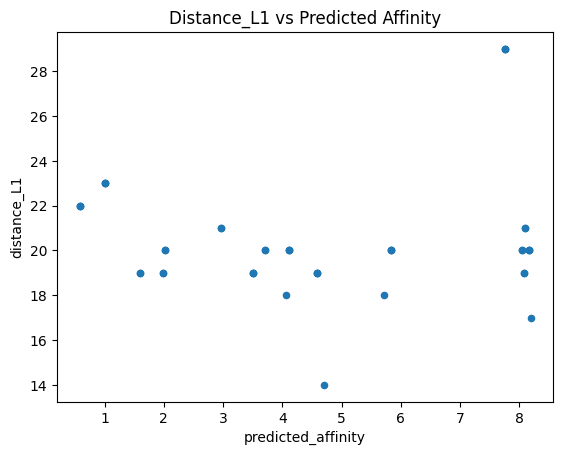

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

ax = df_sorted.plot.scatter(x="predicted_affinity", y="distance_L1", title="Distance_L1 vs Predicted Affinity")
plt.show()





In [8]:
df_sorted

,start_mol,dataset_index_x,smiles,smiles_length,mol_weight,distance_L1,max_bucket_difference,bucket_counts,predicted_affinity,dataset_index_y,molecular_weight,logP,HIA_Hou,hERG,QED,Lipinski
12,12,19,Cc1ccc(CC(=O)N2C[C@H]3CCN(C(=O)[C@H]3C2)c2ccc(...,64.0,446.469,14.0,4.0,"[1, 2, 8, 5, 4, 8]",5.568832,19.0,446.469,3.99012,0.999051,0.886282,0.698066,4.0
23,19,77,CC(C)C(N1C[C@H]2CCN(C(=O)[C@H]2C1)c1ccc(OCC(F)...,72.0,507.528,14.0,3.0,"[2, 1, 8, 5, 4, 8]",4.701901,77.0,507.528,4.71480,0.997500,0.922834,0.551612,3.0
13,13,20,Fc1ccc(CC(=O)N2C[C@H]3CCN(C(=O)[C@H]3C2)c2ccc(...,64.0,450.432,15.0,5.0,"[0, 2, 8, 5, 4, 8]",6.740251,20.0,450.432,3.82080,0.998104,0.881183,0.651236,4.0
7,7,12,CC(C)c1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2...,68.0,446.469,15.0,3.0,"[2, 0, 8, 5, 4, 8]",5.237505,12.0,446.469,4.83370,0.998508,0.876917,0.675875,4.0
24,20,79,OC(CN1C[C@H]2CCN(C(=O)[C@H]2C1)c1ccc(OCC(F)(F)...,66.0,503.348,17.0,5.0,"[0, 2, 6, 6, 4, 7]",3.306608,79.0,503.348,4.95280,0.998956,0.964227,0.606405,3.0
6,6,10,FC(F)(F)Oc1ccc(NC(=O)N2C[C@@H]3CCN(C(=O)[C@@H]...,73.0,503.399,17.0,5.0,"[0, 0, 8, 5, 4, 8]",5.355375,10.0,503.399,5.00060,0.971210,0.826461,0.596643,2.0
9,9,16,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,66.0,489.903,18.0,6.0,"[0, 1, 5, 5, 4, 7]",6.613062,16.0,489.903,3.34970,0.999594,0.770369,0.601753,4.0
10,10,17,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,64.0,454.470,18.0,5.0,"[0, 1, 6, 4, 4, 9]",6.976396,17.0,454.470,3.30130,0.999095,0.912089,0.695531,4.0
15,15,51,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,66.0,488.915,18.0,5.0,"[0, 1, 6, 5, 4, 8]",4.818171,51.0,488.915,3.95470,0.999544,0.889901,0.638834,4.0
11,11,18,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,73.0,538.466,18.0,5.0,"[0, 1, 6, 5, 4, 8]",4.056323,18.0,538.466,4.19990,0.997987,0.927736,0.515830,3.0


In [17]:
import pandas as pd
from pathlib import Path

# Point to your features run (replace with your signature if you know it)
feat_root = Path("../../outputs/features")
sig = "97df27707ad5"  # set to your features signature
admet_path = feat_root / sig / "admet_features.csv"

df = pd.read_csv(admet_path)

# Keep only numeric ADMET columns (drop metadata)
numeric_cols = [c for c in df.columns if c not in {"dataset_index", "smiles"}]
stats = df[numeric_cols].agg(["mean", "min", "max"]).T
stats.columns = ["mean", "min", "max"]

display(stats)


,mean,min,max
molecular_weight,454.732821,82.106000,4685.660000
logP,3.736960,-5.828600,48.547800
HIA_Hou,0.990563,0.007735,1.000000
hERG,0.758101,0.001559,0.997788
QED,0.510876,0.001937,0.947675
Lipinski,3.539405,0.000000,4.000000
